In [1]:
import numpy as np
import pandas as pd

In [ ]:
# Reading the data
column_names = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]

data = pd.read_csv("/Users/sriharika_jajula/Coding/heart_disease_prediction/Data/processed.cleveland.data", names = column_names)

description of the variable in the dataset

1. age:             represents the age of the patient in years (integer)
2. sex:             represents the gender of the patient (categorical variable) [1 = male, 0 = female]
3. cp:              represents the chest pain type experienced by the patient (categorical Variable) [1 = typical angina, 2 = atypical, angina, 3 - non anginal pain, 4 = asymptomatic pain]
4. trestbps:        represents the resting blood pressure of the patient in mm Hg (integer)
5. chol:            represents the serum cholesterol level of the patient in mg/dl (integer)
6. fbs:             represents whether the patient has fasting blood sugar > 120 mg/dl (categorical variable) [1 = true, 0 = false]
7. restecg:        represents the resting electrocardiographic results (categorical variable) [0 = normal, 1 = having ST-T wave abnormality, 2 = showing probable ]
8. thalach:        represents the maximum heart rate achieved by the patient (integer)
9. exang:          represents whether the patient has exercise-induced angina (categorical variable) [1 = yes, 0 = no]
10. oldpeak:        represents the ST depression induced by exercise relative to rest (integer)
11. slope:          represents the slope of the peak exercise ST segment (categorical variable) [1 = upsloping, 2 = flat, 3 = downsloping]
12. ca:             represents the number of major vessels colored by fluoroscopy (integer)
13. thal:           represents the thalassemia type (categorical variable) [3 = normal, 6 = fixed defect, 7 = reversible defect]
14. target: represents the target label indicating the diagnosis of heart disease (label) [0 = no heart disease, 1 = heart disease present]

In [6]:
print("no of rows in the dataset:",data.shape[0])
print("no of columns in the dataset:", data.shape[1])

no of rows in the dataset: 303
no of columns in the dataset: 14


In [7]:
data.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
5,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,3
7,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0
8,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,2
9,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1


In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    str    
 12  thal      303 non-null    str    
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), str(2)
memory usage: 33.3 KB


In [9]:
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,4.000000


In [10]:
data["target"].value_counts()

target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

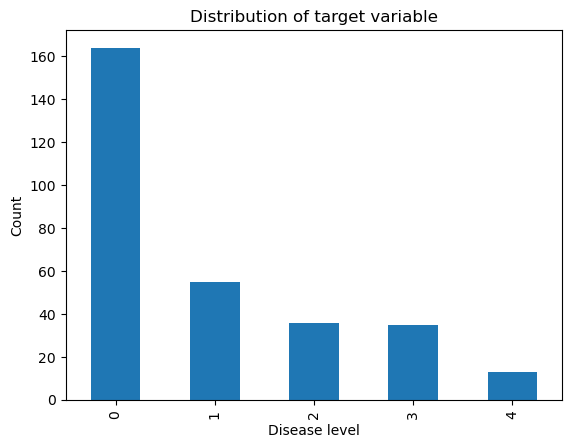

In [12]:
import matplotlib.pyplot as plt

data["target"].value_counts().plot(kind ="bar")
plt.title("Distribution of target variable")
plt.xlabel("Disease level")
plt.ylabel("Count")
plt.show()

The distribution of the target variable is as follows:
- class 0 has highest count of the data points indicating that most of the patients in the dataset do not have heart disease.


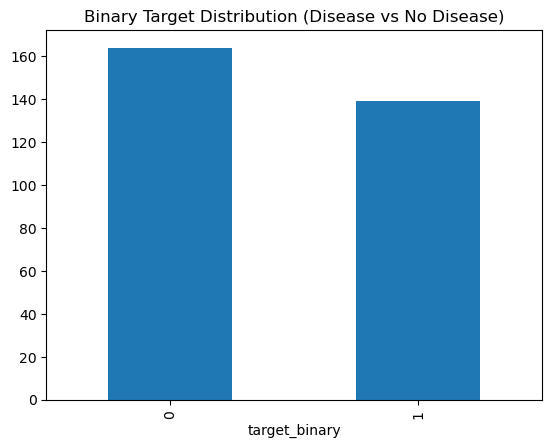

In [13]:
data['target_binary'] = data['target'].apply(lambda x: 1 if x > 0 else 0)

data['target_binary'].value_counts().plot(kind='bar')
plt.title("Binary Target Distribution (Disease vs No Disease)")
plt.show()

When binary classification is performed by converting the target variable into a binary format [Disease or No Disease]. The data can be considered as balanced dataset.

In [15]:
(data['ca'] == "?").sum(), (data['thal'] == "?").sum()
print("percentage of missing values in the dataset is: ", ((data['ca'] == "?").sum() + (data['thal'] == "?").sum()) / data.shape[0] * 100)

percentage of missing values in the dataset is:  1.9801980198019802


Missing values were encoded as "?" in the dataset
Identified 4 missing values in 'ca' and 2 in 'thal'
As the percentage of missing values in the dataset is less than 5%
Choose to drop the rows as the missing values.

In [16]:
data = data.replace("?", np.nan)
data = data.dropna()
data = data.astype(float)

In [17]:
data.info()

<class 'pandas.DataFrame'>
Index: 297 entries, 0 to 301
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            297 non-null    float64
 1   sex            297 non-null    float64
 2   cp             297 non-null    float64
 3   trestbps       297 non-null    float64
 4   chol           297 non-null    float64
 5   fbs            297 non-null    float64
 6   restecg        297 non-null    float64
 7   thalach        297 non-null    float64
 8   exang          297 non-null    float64
 9   oldpeak        297 non-null    float64
 10  slope          297 non-null    float64
 11  ca             297 non-null    float64
 12  thal           297 non-null    float64
 13  target         297 non-null    float64
 14  target_binary  297 non-null    float64
dtypes: float64(15)
memory usage: 37.1 KB


Notes of the EDA process:

1. Dataset contains 303 observations and 14 variables before handling missing values.
2. Dataset contains 297 observations after handling missing values.
3. Missing values were encoded as "?" in the dataset in two variables ["ca" and "thal"].
4. All the variables in the dataset are of numeric type after handling missing values and converting them to float type.
5. Most of the patients in the dataset do not have heart disease.